# Insurance Status and Healthcare Outcomes: An Analysis Using MIMIC-III

## Introduction

This tutorial delves into the critical relationship between insurance status and healthcare outcomes, using the rich and comprehensive MIMIC-III (Medical Information Mart for Intensive Care III) dataset. Understanding how insurance coverage influences patient experiences and outcomes is essential for identifying potential disparities and informing policy decisions.

### The Importance of Insurance in Healthcare

In the United States, access to healthcare is often intricately linked to insurance coverage. Insurance acts as a financial intermediary, facilitating access to medical services. However, the type of insurance a patient holds can significantly impact:

* **Access to Care:** Different insurance plans offer varying levels of coverage, influencing which providers and treatments are accessible.
* **Treatment Patterns:** Insurance may dictate the types of procedures, medications, and services a patient receives.
* **Healthcare Costs:** Out-of-pocket expenses, deductibles, and co-pays can vary widely, affecting a patient's ability to afford necessary care.
* **Hospital Length of Stay and Readmissions:** Insurance policies can affect the length of hospital stays and the likelihood of readmission.
* **Mortality and Complication Rates:** Disparities in access and treatment may lead to differences in patient outcomes.

### Ethical Considerations

Analyzing insurance status and healthcare outcomes raises important ethical considerations. It is crucial to:

* Protect patient privacy and confidentiality.
* Avoid perpetuating harmful stereotypes or biases.
* Interpret findings responsibly and consider the broader social and economic context.

### Project Goals

This tutorial aims to:

* Explore the distribution of insurance types within the MIMIC-III dataset.
* Analyze the relationship between insurance status and key healthcare outcomes, such as length of stay, readmission rates, and mortality.
* Identify potential disparities in treatment patterns across different insurance groups.
* Provide practical examples of data analysis techniques using Python and relevant libraries (e.g., pandas, NumPy, scikit-learn, matplotlib, seaborn).
* Provide clear and concise code examples.

### Dataset Overview

We will be using the MIMIC-III dataset, a freely available, de-identified database comprising information related to patients admitted to critical care units of the Beth Israel Deaconess Medical Center between 2001 and 2012. It contains a wealth of clinical data, including demographics, diagnoses, procedures, medications, and insurance information.

### Notebook Structure

This notebook is organized as follows:

1.  **Data Preparation:** Accessing, cleaning, and merging relevant tables from MIMIC-III.
2.  **Exploratory Data Analysis (EDA):** Visualizing and summarizing the distribution of insurance types and key outcomes.
3.  **Statistical Analysis:** Conducting comparative analyses and hypothesis testing.
4.  **Advanced Analysis:** Implementing propensity score matching and predictive modeling.
5.  **Conclusions and Implications:** Interpreting the findings and discussing potential policy implications.

Let's begin by setting up our environment and loading the necessary libraries.

### Data Preperation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import timedelta
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [33]:

# Load data from CSV files
patients = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/PATIENTS.csv.gz')
admissions = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/ADMISSIONS.csv.gz')
diagnoses_icd = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/DIAGNOSES_ICD.csv.gz')
d_icd_diagnoses = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/D_ICD_DIAGNOSES.csv.gz')
procedure_icd = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/PROCEDURES_ICD.csv.gz')
d_icd_procedures = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/D_ICD_PROCEDURES.csv.gz')
services = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/SERVICES.csv.gz')
icustays = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/ICUSTAYS.csv.gz')
cptevents = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/CPTEVENTS.csv.gz')
transfers = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/TRANSFERS.csv.gz')
noteevents = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/NOTEEVENTS.csv.gz')
d_cpt = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/D_CPT.csv.gz')


# Exploratory Data Analysis

### Research Questions
Do patients who have private insurance have better outcomes than those with public insurance or medicare / medicaid? How does insurance status impact care?

1. Do patients with different insurance types experience different lengths of stay for similar conditions?
2. Are there differences in readmission rates based on insurance status?
3. Do treatment patterns (procedures, medications) vary by insurance type?
4. Are there disparities in mortality rates or complications across insurance groups?
5. Does time-to-treatment differ based on insurance status?

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (12, 8)

print("Loading MIMIC-III data...")
# Load data from CSV files
patients = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/PATIENTS.csv.gz')
admissions = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/ADMISSIONS.csv.gz')
diagnoses_icd = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/DIAGNOSES_ICD.csv.gz')
procedure_icd = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/PROCEDURES_ICD.csv.gz')
icustays = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/ICUSTAYS.csv.gz')

print("Processing data...")
# Step 1: Merge patients and admissions data
df = pd.merge(patients, admissions, on='SUBJECT_ID')

# Step 2: Convert date columns to datetime
print("Converting date columns...")
df['ADMITTIME'] = pd.to_datetime(df['ADMITTIME'], errors='coerce')
df['DISCHTIME'] = pd.to_datetime(df['DISCHTIME'], errors='coerce')
df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
df['DEATHTIME'] = pd.to_datetime(df['DEATHTIME'], errors='coerce')

# Step 3: Calculate length of stay in days
print("Calculating length of stay...")
mask = (~df['ADMITTIME'].isna()) & (~df['DISCHTIME'].isna())
df['LOS_DAYS'] = np.nan
df.loc[mask, 'LOS_DAYS'] = (df.loc[mask, 'DISCHTIME'] - df.loc[mask, 'ADMITTIME']).dt.total_seconds() / (24 * 60 * 60)

# Step 4: Calculate age using relativedelta
print("Calculating patient ages with relativedelta...")
# Only calculate for rows with valid dates
valid_dates = (~df['ADMITTIME'].isna()) & (~df['DOB'].isna())
df['AGE'] = np.nan

# Use a more efficient vectorized approach if possible
try:
    from tqdm import tqdm
    # Use tqdm if available for progress tracking
    print("Processing ages row by row (this may take a while)...")
    for idx in tqdm(df[valid_dates].index):
        try:
            df.loc[idx, 'AGE'] = relativedelta(df.loc[idx, 'ADMITTIME'], df.loc[idx, 'DOB']).years
        except:
            pass
except ImportError:
    # Fallback without tqdm
    print("Processing ages row by row (this may take a while)...")
    for idx in df[valid_dates].index:
        try:
            df.loc[idx, 'AGE'] = relativedelta(df.loc[idx, 'ADMITTIME'], df.loc[idx, 'DOB']).years
        except:
            pass

# Step 5: Filter out unrealistic age values
print("Filtering out unrealistic age values...")
df = df[(df['AGE'] >= 0) & (df['AGE'] <= 100)]
print(f"Remaining records after age filtering: {len(df)}")

# Step 6: Add insurance category
print("Categorizing insurance types...")
def categorize_insurance(insurance):
    if pd.isna(insurance):
        return 'Unknown'
    elif 'MEDICAID' in insurance.upper():
        return 'Medicaid'
    elif 'MEDICARE' in insurance.upper():
        return 'Medicare'
    elif 'PRIVATE' in insurance.upper():
        return 'Private'
    elif 'SELF' in insurance.upper():
        return 'Self-Pay'
    else:
        return 'Other'

df['INSURANCE_CATEGORY'] = df['INSURANCE'].apply(categorize_insurance)

# Step 7: Add mortality indicator
print("Adding mortality indicators...")
df['MORTALITY'] = (~df['DEATHTIME'].isna()).astype(int)

# Step 8: Add ICU stay information
print("Adding ICU stay information...")
df['ICU_STAY'] = df['HADM_ID'].isin(icustays['HADM_ID']).astype(int)

# Step 9: Add diagnosis and procedure counts
print("Adding diagnosis counts...")
diagnosis_counts = diagnoses_icd.groupby('HADM_ID').size().reset_index(name='DIAGNOSIS_COUNT')
df = pd.merge(df, diagnosis_counts, on='HADM_ID', how='left')
df['DIAGNOSIS_COUNT'] = df['DIAGNOSIS_COUNT'].fillna(0)

print("Adding procedure counts...")
procedure_counts = procedure_icd.groupby('HADM_ID').size().reset_index(name='PROCEDURE_COUNT')
df = pd.merge(df, procedure_counts, on='HADM_ID', how='left')
df['PROCEDURE_COUNT'] = df['PROCEDURE_COUNT'].fillna(0)

# Step 10: Create age groups for analysis
print("Creating age groups...")
df['AGE_GROUP'] = pd.cut(df['AGE'], 
                         bins=[0, 18, 30, 40, 50, 60, 70, 80, 90, 100],
                         labels=['0-18', '19-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100'])

# Step 11: Filter for valid LOS
print("Filtering for valid length of stay...")
df = df[df['LOS_DAYS'] > 0]
print(f"Final dataset size: {len(df)} records")

# Step 12: Save processed data
print("Saving processed data...")
df.to_csv('processed_mimic_data.csv', index=False)

print("\nData processing complete. Generating visualizations...")

# VISUALIZATIONS

# 1. Age distribution by gender
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='AGE', hue='GENDER', bins=20, kde=True)
plt.title('Age Distribution by Gender', fontsize=16)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.savefig('age_distribution_by_gender.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. Length of stay distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='LOS_DAYS', bins=30, kde=True)
plt.axvline(df['LOS_DAYS'].median(), color='red', linestyle='--', 
           label=f'Median: {df["LOS_DAYS"].median():.2f} days')
plt.title('Length of Stay Distribution', fontsize=16)
plt.xlabel('Length of Stay (days)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xlim(0, df['LOS_DAYS'].quantile(0.95))  # Limit x-axis to 95th percentile for better visualization
plt.legend()
plt.savefig('length_of_stay_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# 3. Insurance distribution
plt.figure(figsize=(10, 6))
insurance_counts = df['INSURANCE_CATEGORY'].value_counts()
sns.barplot(x=insurance_counts.index, y=insurance_counts.values)
plt.title('Distribution of Insurance Types', fontsize=16)
plt.xlabel('Insurance Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
for i, count in enumerate(insurance_counts.values):
    plt.text(i, count + 100, f'{count}', ha='center')
plt.savefig('insurance_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# 4. Average LOS by insurance type
plt.figure(figsize=(10, 6))
avg_los_by_insurance = df.groupby('INSURANCE_CATEGORY')['LOS_DAYS'].mean().sort_values(ascending=False)
sns.barplot(x=avg_los_by_insurance.index, y=avg_los_by_insurance.values)
plt.title('Average Length of Stay by Insurance Type', fontsize=16)
plt.xlabel('Insurance Category', fontsize=12)
plt.ylabel('Average LOS (days)', fontsize=12)
plt.xticks(rotation=45)
for i, los in enumerate(avg_los_by_insurance.values):
    plt.text(i, los + 0.2, f'{los:.2f}', ha='center')
plt.savefig('avg_los_by_insurance.png', dpi=300, bbox_inches='tight')
plt.close()

# 5. Mortality rate by age group
plt.figure(figsize=(12, 6))
mortality_by_age = df.groupby('AGE_GROUP')['MORTALITY'].mean() * 100
sns.barplot(x=mortality_by_age.index, y=mortality_by_age.values)
plt.title('Mortality Rate by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Mortality Rate (%)', fontsize=12)
plt.xticks(rotation=45)
for i, rate in enumerate(mortality_by_age.values):
    plt.text(i, rate + 0.5, f'{rate:.2f}%', ha='center')
plt.savefig('mortality_by_age.png', dpi=300, bbox_inches='tight')
plt.close()

# 6. Admission types distribution
plt.figure(figsize=(10, 6))
admission_type_counts = df['ADMISSION_TYPE'].value_counts()
sns.barplot(x=admission_type_counts.index, y=admission_type_counts.values)
plt.title('Distribution of Admission Types', fontsize=16)
plt.xlabel('Admission Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
for i, count in enumerate(admission_type_counts.values):
    plt.text(i, count + 100, f'{count}', ha='center')
plt.savefig('admission_types_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# 7. ICU vs non-ICU mortality rates
plt.figure(figsize=(10, 6))
icu_mortality = df.groupby('ICU_STAY')['MORTALITY'].mean() * 100
labels = ['Non-ICU', 'ICU']
sns.barplot(x=labels, y=icu_mortality.values)
plt.title('Mortality Rate: ICU vs Non-ICU Admissions', fontsize=16)
plt.xlabel('ICU Stay', fontsize=12)
plt.ylabel('Mortality Rate (%)', fontsize=12)
for i, rate in enumerate(icu_mortality.values):
    plt.text(i, rate + 0.5, f'{rate:.2f}%', ha='center')
plt.savefig('icu_mortality.png', dpi=300, bbox_inches='tight')
plt.close()

# 8. Length of stay by service type (if available)
if 'CURR_SERVICE' in df.columns:
    plt.figure(figsize=(14, 8))
    service_los = df.groupby('CURR_SERVICE')['LOS_DAYS'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=service_los.index, y=service_los.values)
    plt.title('Average Length of Stay by Service Type (Top 10)', fontsize=16)
    plt.xlabel('Service', fontsize=12)
    plt.ylabel('Average LOS (days)', fontsize=12)
    plt.xticks(rotation=90)
    for i, los in enumerate(service_los.values):
        plt.text(i, los + 0.2, f'{los:.2f}', ha='center')
    plt.savefig('los_by_service.png', dpi=300, bbox_inches='tight')
    plt.close()

# 9. Correlation between number of diagnoses and length of stay
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='DIAGNOSIS_COUNT', y='LOS_DAYS', alpha=0.3)
plt.title('Correlation: Number of Diagnoses vs Length of Stay', fontsize=16)
plt.xlabel('Number of Diagnoses', fontsize=12)
plt.ylabel('Length of Stay (days)', fontsize=12)
plt.ylim(0, df['LOS_DAYS'].quantile(0.95))
# Calculate and display correlation
correlation = df['DIAGNOSIS_COUNT'].corr(df['LOS_DAYS'])
plt.annotate(f'Correlation: {correlation:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)
plt.savefig('diagnoses_los_correlation.png', dpi=300, bbox_inches='tight')
plt.close()

# 10. Correlation between number of procedures and length of stay
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='PROCEDURE_COUNT', y='LOS_DAYS', alpha=0.3)
plt.title('Correlation: Number of Procedures vs Length of Stay', fontsize=16)
plt.xlabel('Number of Procedures', fontsize=12)
plt.ylabel('Length of Stay (days)', fontsize=12)
plt.ylim(0, df['LOS_DAYS'].quantile(0.95))
# Calculate and display correlation
correlation = df['PROCEDURE_COUNT'].corr(df['LOS_DAYS'])
plt.annotate(f'Correlation: {correlation:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)
plt.savefig('procedures_los_correlation.png', dpi=300, bbox_inches='tight')
plt.close()

Loading MIMIC-III data...
Processing data...
Converting date columns...
Calculating length of stay...
Calculating patient ages with relativedelta...
Processing ages row by row (this may take a while)...


100%|██████████| 58976/58976 [00:08<00:00, 6658.95it/s]


Filtering out unrealistic age values...
Remaining records after age filtering: 56360
Categorizing insurance types...
Adding mortality indicators...
Adding ICU stay information...
Adding diagnosis counts...
Adding procedure counts...
Creating age groups...
Filtering for valid length of stay...
Final dataset size: 56268 records
Saving processed data...

Data processing complete. Generating visualizations...


In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from dateutil.relativedelta import relativedelta

print("Starting data preparation...")

# Load the cleaned dataset
df = pd.read_csv('processed_mimic_data.csv')

# One-hot encode insurance categories
print("Encoding insurance categories...")
insurance_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
insurance_encoded = insurance_encoder.fit_transform(df[['INSURANCE_CATEGORY']])
insurance_columns = insurance_encoder.get_feature_names_out(['INSURANCE_CATEGORY'])
df[insurance_columns] = insurance_encoded

# Normalize continuous variables
scaler = StandardScaler()
df[['AGE', 'LOS_DAYS', 'DIAGNOSIS_COUNT', 'PROCEDURE_COUNT']] = scaler.fit_transform(
    df[['AGE', 'LOS_DAYS', 'DIAGNOSIS_COUNT', 'PROCEDURE_COUNT']]
)

# Handle missing values (fill with 0 for simplicity)
df.fillna(0, inplace=True)

# Define target variables
df['READMISSION'] = df.duplicated(subset=['SUBJECT_ID'], keep=False).astype(int)

print("Feature engineering complete.")


Starting data preparation...
Encoding insurance categories...
Feature engineering complete.


Performing exploratory data analysis...


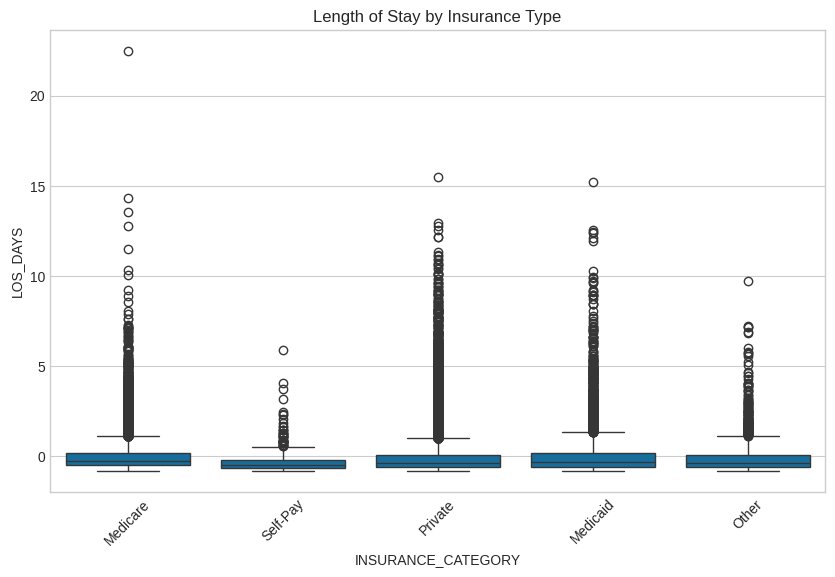

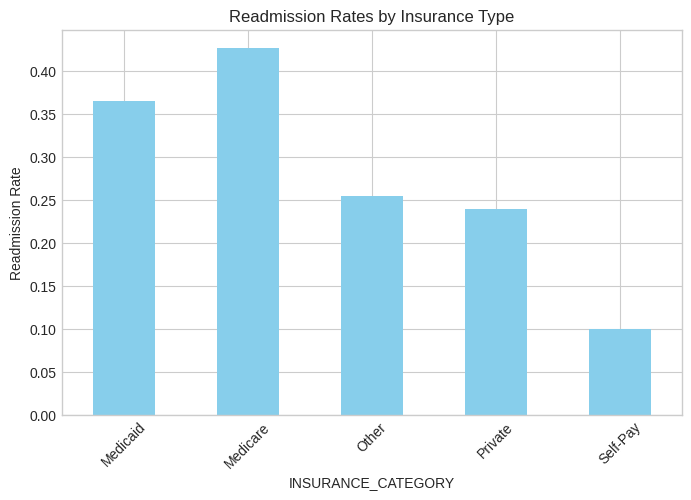

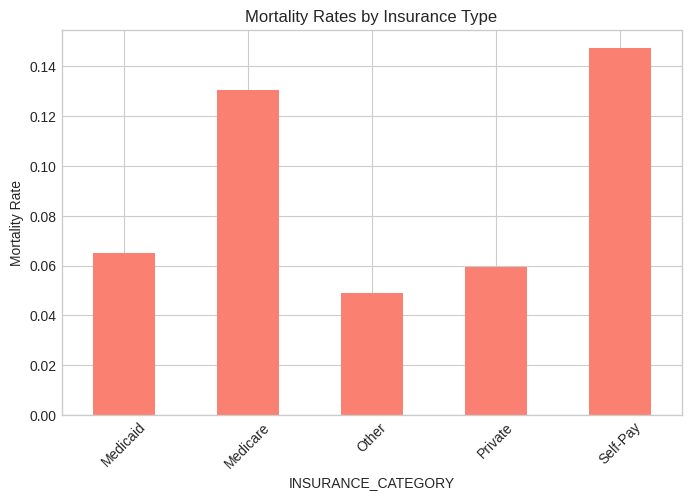

EDA complete.


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Performing exploratory data analysis...")

# Boxplot of Length of Stay across Insurance Types
plt.figure(figsize=(10,6))
sns.boxplot(x=df['INSURANCE_CATEGORY'], y=df['LOS_DAYS'])
plt.xticks(rotation=45)
plt.title("Length of Stay by Insurance Type")
plt.show()

# Readmission Rate by Insurance Type
readmission_rates = df.groupby('INSURANCE_CATEGORY')['READMISSION'].mean()
readmission_rates.plot(kind='bar', color='skyblue', figsize=(8,5))
plt.title("Readmission Rates by Insurance Type")
plt.ylabel("Readmission Rate")
plt.xticks(rotation=45)
plt.show()

# Mortality Rates by Insurance Type
mortality_rates = df.groupby('INSURANCE_CATEGORY')['MORTALITY'].mean()
mortality_rates.plot(kind='bar', color='salmon', figsize=(8,5))
plt.title("Mortality Rates by Insurance Type")
plt.ylabel("Mortality Rate")
plt.xticks(rotation=45)
plt.show()

print("EDA complete.")


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("Training machine learning models...")

# Define features and targets
X = df[['AGE', 'LOS_DAYS', 'DIAGNOSIS_COUNT', 'PROCEDURE_COUNT'] + list(insurance_columns)]
y_mortality = df['MORTALITY']
y_readmission = df['READMISSION']

# Split data into train/test sets
X_train, X_test, y_train_mortality, y_test_mortality = train_test_split(X, y_mortality, test_size=0.2, random_state=42)
X_train, X_test, y_train_readmission, y_test_readmission = train_test_split(X, y_readmission, test_size=0.2, random_state=42)

# Train mortality prediction model (Random Forest)
mortality_model = RandomForestClassifier(n_estimators=100, random_state=42)
mortality_model.fit(X_train, y_train_mortality)
y_pred_mortality = mortality_model.predict(X_test)

print("Mortality Model Performance:")
print(classification_report(y_test_mortality, y_pred_mortality))

# Train readmission prediction model (Logistic Regression)
readmission_model = LogisticRegression(max_iter=1000)
readmission_model.fit(X_train, y_train_readmission)
y_pred_readmission = readmission_model.predict(X_test)

print("Readmission Model Performance:")
print(classification_report(y_test_readmission, y_pred_readmission))

print("Machine learning predictions complete.")


Training machine learning models...
Mortality Model Performance:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     10252
           1       0.48      0.17      0.25      1002

    accuracy                           0.91     11254
   macro avg       0.70      0.58      0.60     11254
weighted avg       0.88      0.91      0.89     11254

Readmission Model Performance:
              precision    recall  f1-score   support

           0       0.69      0.91      0.79      7530
           1       0.50      0.19      0.27      3724

    accuracy                           0.67     11254
   macro avg       0.59      0.55      0.53     11254
weighted avg       0.63      0.67      0.61     11254

Machine learning predictions complete.


Performing PCA and t-SNE for visualization...


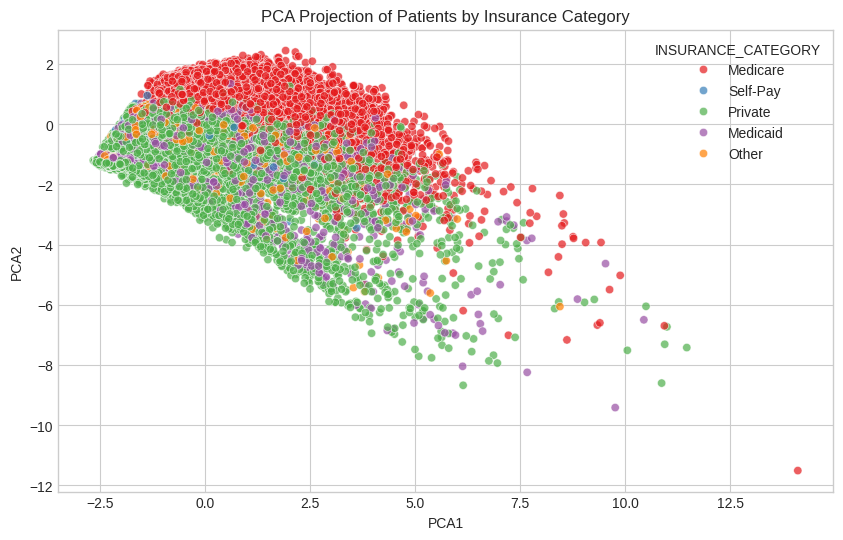

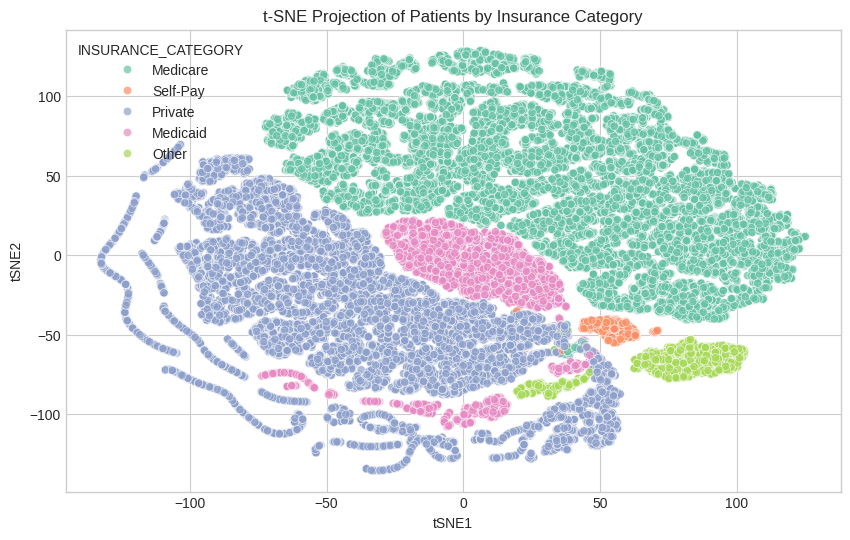

Dimensionality reduction complete.


In [38]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Performing PCA and t-SNE for visualization...")

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='INSURANCE_CATEGORY', data=df, palette='Set1', alpha=0.7)
plt.title("PCA Projection of Patients by Insurance Category")
plt.show()

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(X)
df['tSNE1'] = tsne_result[:,0]
df['tSNE2'] = tsne_result[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='tSNE1', y='tSNE2', hue='INSURANCE_CATEGORY', data=df, palette='Set2', alpha=0.7)
plt.title("t-SNE Projection of Patients by Insurance Category")
plt.show()

print("Dimensionality reduction complete.")


Calculating SHAP values for feature importance...


<Figure size 1200x800 with 0 Axes>

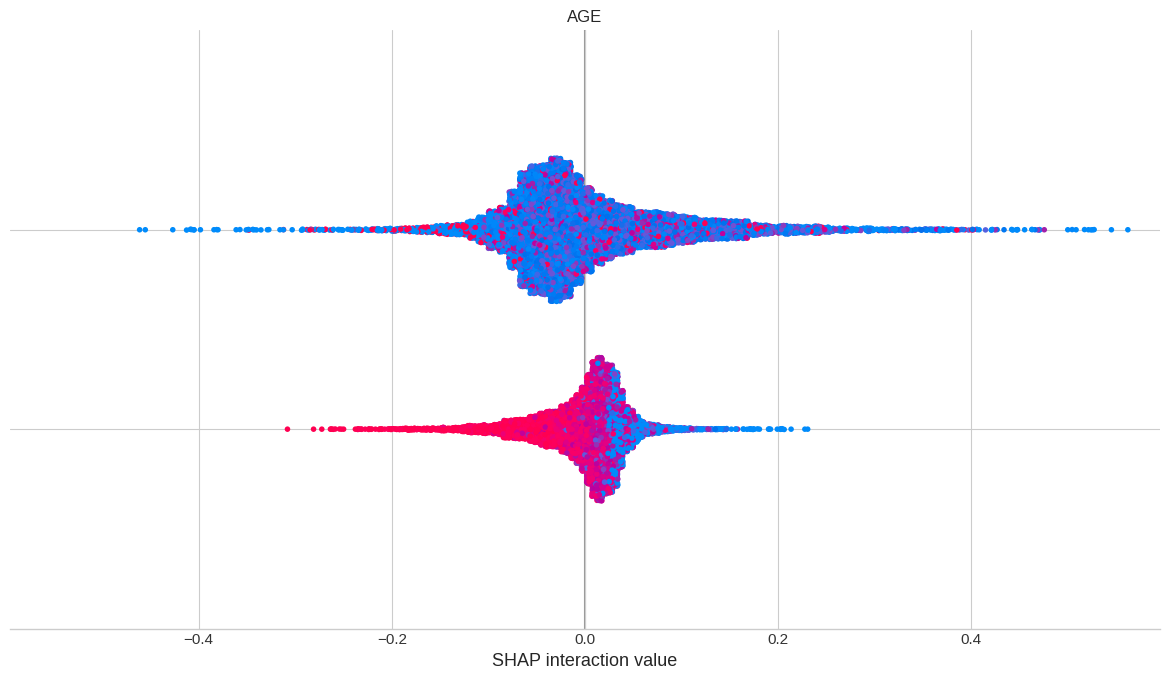

In [40]:
import shap

print("Calculating SHAP values for feature importance...")

# Initialize SHAP explainer
explainer = shap.TreeExplainer(mortality_model)
shap_values = explainer.shap_values(X_test)

# Summary plot for feature importance
shap.summary_plot(shap_values, X_test, feature_names=X.columns)


Performing survival analysis...


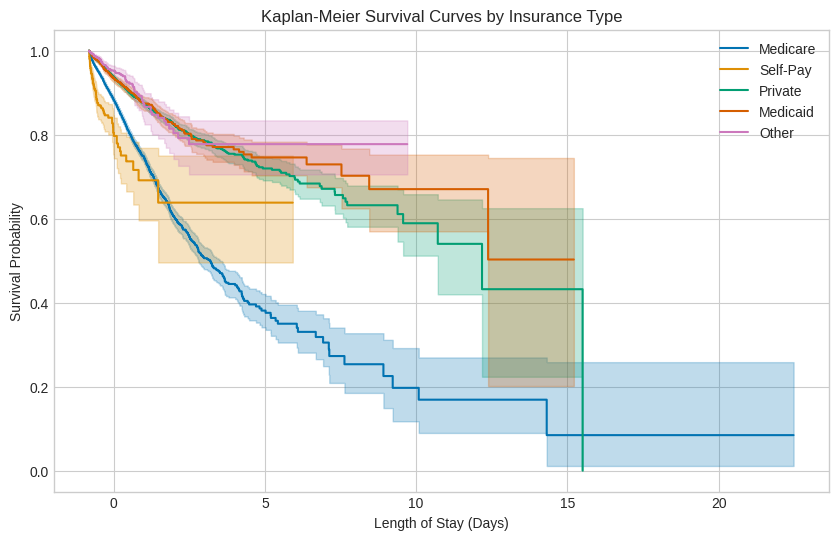

In [42]:
from lifelines import KaplanMeierFitter

print("Performing survival analysis...")

kmf = KaplanMeierFitter()

plt.figure(figsize=(10,6))
for insurance in df['INSURANCE_CATEGORY'].unique():
    mask = df['INSURANCE_CATEGORY'] == insurance
    kmf.fit(df.loc[mask, 'LOS_DAYS'], event_observed=df.loc[mask, 'MORTALITY'])
    kmf.plot_survival_function(label=insurance)

plt.title("Kaplan-Meier Survival Curves by Insurance Type")
plt.ylabel("Survival Probability")
plt.xlabel("Length of Stay (Days)")
plt.show()


Performing K-Means Clustering...


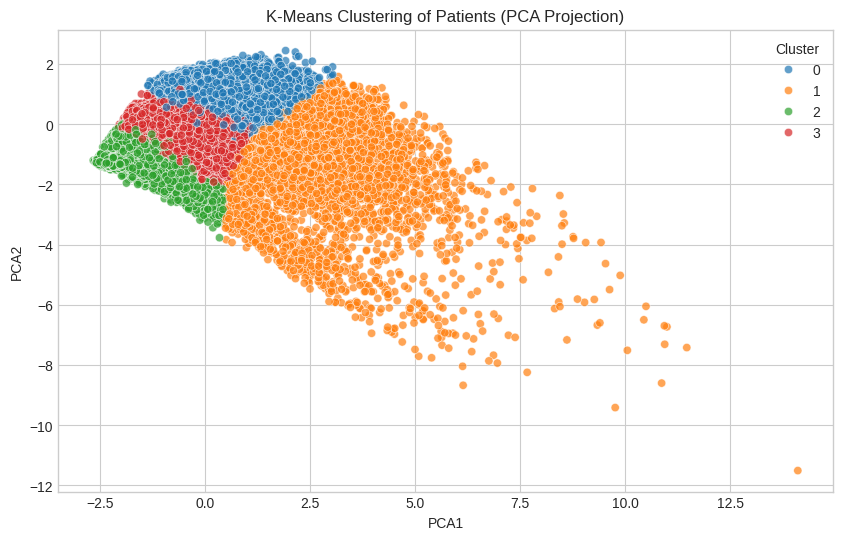

In [43]:
from sklearn.cluster import KMeans

print("Performing K-Means Clustering...")

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(10,6))
sns.scatterplot(x=df['PCA1'], y=df['PCA2'], hue=df['Cluster'], palette='tab10', alpha=0.7)
plt.title("K-Means Clustering of Patients (PCA Projection)")
plt.show()
